# The histogram-recovery encoder for general $m$

[encode.ipynb](encode.ipynb) implements the encoder of Deng and Raviv,
*Efficient Vector Symbolic Architectures from Histogram Recovery* (arXiv:2511.01838,
local copy `histo.pdf`) for the special case $m = 1$, where the Reed--Solomon alphabet is
the prime field $\mathbb{F}_p$ and all arithmetic is plain integer arithmetic mod $p$.

This notebook does the general case: Reed--Solomon over $\mathbb{F}_{p^m}$, so
$N = p^m$ and a codeword lives in $\mathbb{C}^{p^{2m}}$.

| Quantity | `encode.ipynb` ($m=1$) | here (general $m$) |
|---|---|---|
| RS alphabet | $\mathbb{F}_p$, integers `0..p-1` | $\mathbb{F}_{p^m}$, integers `0..p^m-1` |
| Block length | $N = p$ | $N = p^m$ |
| Hypervector dimension | $p^2$ | $p^{2m} = N^2$ |
| Code size | $p^K$ | $p^{mK} = N^K$ |
| Field arithmetic | `% p` | `GF.ADD` / `GF.MUL` tables |

Three things do **not** change, and they are the reason the whole exercise is tractable:

1. $\phi$ is untouched. The inner Hadamard code emits symbols in $\mathbb{F}_p$ whatever
   $m$ is, so codeword entries are always $p$-th roots of unity.
2. Every figure of merit is a function of $N$ alone, so the formulas carry over verbatim
   under $N = p^m$:
   $$d_{\min} = N - K + 1, \qquad \mu = \frac{K-1}{N}, \qquad
     l_{\max} = \frac{2N - d_{\min}}{2(N - d_{\min})}$$
3. Binding is still the point-wise product, and still corresponds to addition in the
   message space -- but that addition is now $\mathbb{F}_{p^m}$ addition, **not** `% p^m`.

The last sections validate all of this: against the paper's own statements, and against
`encode.ipynb` by checking that this notebook reproduces it exactly at $m = 1$.

In [1]:
import contextlib
import io
import json
import os
from itertools import product

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sympy import primerange

%matplotlib inline

np.set_printoptions(precision=3, suppress=True, linewidth=120)
_rng = np.random.default_rng(0)
os.makedirs("figures", exist_ok=True)

## Step 0 --- the field $\mathbb{F}_{p^m}$

This is the part $m = 1$ let us skip. Each Reed--Solomon symbol is an element of
$\mathbb{F}_{p^m}$, and to hand it to $f_{\mathrm{Had}}$ the paper requires it be
"represented as a vector in $\mathbb{F}_p^m$" (§III).

So build $\mathbb{F}_{p^m}$ as $\mathbb{F}_p[x]/(f)$ for a monic irreducible $f$ of degree
$m$, and identify a field element with its coefficient vector in the basis
$\{1, x, \ldots, x^{m-1}\}$. That map is an isomorphism of *additive* groups
$(\mathbb{F}_{p^m}, +) \cong (\mathbb{F}_p^m, +)$, which is the only structure
$f_{\mathrm{Had}}$ and $\phi$ depend on.

Elements are stored as plain integers $0, \ldots, p^m - 1$; an integer's base-$p$ digits
*are* its coefficient vector. `ADD` and `MUL` are precomputed $q \times q$ tables, which
keeps the Reed--Solomon step readable. These two cells are lifted from
[rs_hadamard_encoder.ipynb](rs_hadamard_encoder.ipynb).

In [2]:
def poly_trim(a):
    a = list(a)
    while len(a) > 1 and a[-1] == 0:
        a.pop()
    return a


def poly_mul(a, b, p):
    out = [0] * (len(a) + len(b) - 1)
    for i, ai in enumerate(a):
        if ai:
            for j, bj in enumerate(b):
                out[i + j] = (out[i + j] + ai * bj) % p
    return poly_trim(out)


def poly_divmod(a, b, p):
    """Quotient and remainder of a / b over F_p (coefficients low -> high)."""
    a, b = poly_trim(a), poly_trim(b)
    db = len(b) - 1
    inv = pow(b[-1], -1, p)
    if db == 0:                                  # b is a nonzero constant
        return poly_trim([x * inv % p for x in a]), [0]
    if len(a) - 1 < db:
        return [0], a
    quo, rem = [0] * (len(a) - db), list(a)
    for i in range(len(a) - 1, db - 1, -1):
        c = rem[i] * inv % p
        if c:
            quo[i - db] = c
            for j in range(db + 1):
                rem[i - db + j] = (rem[i - db + j] - c * b[j]) % p
    return poly_trim(quo), poly_trim(rem[:db])


def monic_polys(p, d):
    """All monic degree-d polynomials over F_p."""
    for tail in product(range(p), repeat=d):
        yield list(tail) + [1]


def is_irreducible(f, p):
    """Monic f is irreducible over F_p iff it has no monic factor of degree <= deg(f)/2."""
    deg = len(f) - 1
    if deg <= 1:
        return True
    return not any(poly_divmod(f, g, p)[1] == [0]
                   for d in range(1, deg // 2 + 1) for g in monic_polys(p, d))


def find_irreducible(p, m):
    for f in monic_polys(p, m):
        if is_irreducible(f, p):
            return f
    raise RuntimeError(f"no irreducible polynomial of degree {m} over F_{p}")

In [3]:
class GF:
    """F_{p^m} as F_p[x]/(f). Element <-> int <-> base-p coefficient vector."""

    def __init__(self, p, m):
        self.p, self.m, self.q = p, m, p ** m
        self.modulus = find_irreducible(p, m)
        self._pw = p ** np.arange(m)
        # vec[a] is the F_p^m coordinate vector of a -- the paper's "representing each
        # F_{p^m} entry as a vector in F_p^m".
        self.vec = np.array([[(a // p ** k) % p for k in range(m)] for a in range(self.q)],
                            dtype=np.int64)
        self.one = self.from_vec([1] + [0] * (m - 1))

        self.ADD = np.zeros((self.q, self.q), dtype=np.int64)
        self.MUL = np.zeros((self.q, self.q), dtype=np.int64)
        for a in range(self.q):
            for b in range(self.q):
                self.ADD[a, b] = self.from_vec((self.vec[a] + self.vec[b]) % p)
                prod = poly_divmod(poly_mul(list(self.vec[a]), list(self.vec[b]), p),
                                   self.modulus, p)[1]
                self.MUL[a, b] = self.from_vec((prod + [0] * m)[:m])

        self.NEG = np.array([self.from_vec((-self.vec[a]) % p) for a in range(self.q)])
        self.INV = np.zeros(self.q, dtype=np.int64)      # INV[0] is unused
        for a in range(1, self.q):
            self.INV[a] = int(np.flatnonzero(self.MUL[a] == self.one)[0])

    def from_vec(self, v):
        return int(np.asarray(v, dtype=np.int64) @ self._pw)

    def sub(self, a, b):
        return self.ADD[a, self.NEG[b]]

    def __repr__(self):
        return f"GF({self.p}^{self.m})"


F = GF(2, 4)
print(f"{F}: modulus f(x) = {F.modulus} (coefficients low -> high), q = {F.q}")
print(f"element 11 <-> coefficient vector {F.vec[11]}")

assert (F.ADD[0] == np.arange(F.q)).all(), "0 is not the additive identity"
assert (F.MUL[F.one] == np.arange(F.q)).all(), "1 is not the multiplicative identity"
assert (F.ADD == F.ADD.T).all() and (F.MUL == F.MUL.T).all(), "not commutative"
for a in range(1, F.q):
    assert sorted(F.MUL[a].tolist()) == list(range(F.q)), f"{a} has no inverse"
    assert F.MUL[a, F.INV[a]] == F.one
print(f"{F} verified: commutative, unital, every nonzero element invertible")

GF(2^4): modulus f(x) = [1, 0, 0, 1, 1] (coefficients low -> high), q = 16
element 11 <-> coefficient vector [1 1 0 1]
GF(2^4) verified: commutative, unital, every nonzero element invertible


## Step 1 --- $\phi$, unchanged

$\phi$ maps $(\mathbb{F}_p, +)$ to $(\{\zeta^i\}_{i=0}^{p-1}, \cdot)$ for a primitive
$p$-th root of unity $\zeta$. Its domain is $\mathbb{F}_p$, not $\mathbb{F}_{p^m}$, so it
is literally the same function as in `encode.ipynb` -- $m$ never enters. Note the $p = 2$
case: $\phi$ becomes real-valued, mapping to $\{+1, -1\}$.

In [4]:
def phi(a, p):
    """Map F_p elements to p-th roots of unity. Identical to encode.ipynb."""
    a = np.asarray(a)
    return np.exp(2j * np.pi * a / p)


for _p in (2, 3, 5):
    _a, _b = 1, _p - 1
    assert np.allclose(phi(_a, _p) * phi(_b, _p), phi((_a + _b) % _p, _p))
print("phi is an isomorphism onto the p-th roots of unity for p = 2, 3, 5")
print(f"p = 2 makes phi real: phi([0, 1], 2).real = {phi([0, 1], 2).real}")

phi is an isomorphism onto the p-th roots of unity for p = 2, 3, 5
p = 2 makes phi real: phi([0, 1], 2).real = [ 1. -1.]


## Step 2 --- the Hadamard inner code, and the one trap

The paper defines $f_{\mathrm{Had}}(a) = (ab^\top)_{b \in \mathbb{F}_p^m}$. That
$ab^\top$ is the $\mathbb{F}_p$-**bilinear form on the coefficient vectors** -- a dot
product mod $p$ -- and *not* multiplication in $\mathbb{F}_{p^m}$.

At $m = 1$ the two coincide, both reducing to $a \cdot b \bmod p$. That is why
`encode.ipynb`'s `np.outer(idx, idx) % p` is correct there, and why reaching for `F.MUL`
when generalising is a plausible-looking mistake that stays invisible until $m > 1$. The
cell below asserts both halves of that claim.

In [5]:
def hadamard_exponents(F):
    """L[b, a] = <vec(a), vec(b)> mod p -- the F_p-bilinear form, NOT F.MUL."""
    return (F.vec @ F.vec.T) % F.p


def hadamard_matrix(F):
    """The q x q Hadamard matrix; column a is phi(f_Had(a))."""
    return phi(hadamard_exponents(F), F.p)


# at m = 1 the bilinear form and field multiplication agree ...
for _p in (2, 3, 5, 7):
    _F = GF(_p, 1)
    assert (hadamard_exponents(_F) == _F.MUL).all(), f"m=1 mismatch at p={_p}"

# ... and for m > 1 they never do, which is the trap
for _p, _m in [(2, 2), (2, 3), (2, 4), (3, 2), (3, 3), (5, 2)]:
    _F = GF(_p, _m)
    assert not (hadamard_exponents(_F) == _F.MUL).all(), f"expected divergence at {_F}"
print("bilinear form == F.MUL at m = 1, and differs for every m > 1 tested")

# H is a genuine Hadamard matrix: H^dagger H = N I
for _p, _m in [(2, 3), (3, 2), (5, 1)]:
    _F = GF(_p, _m)
    _H = hadamard_matrix(_F)
    assert np.allclose(_H.conj().T @ _H, _F.q * np.eye(_F.q)), f"H^dag H != N I at {_F}"
print("H^dagger H = N I verified for (p, m) = (2, 3), (3, 2), (5, 1)")

_F = GF(2, 3)
print("\nf_Had exponents for GF(2^3), i.e. dot product of coefficient vectors mod 2:")
print(hadamard_exponents(_F))
print("the field multiplication table, for comparison -- NOT the same matrix:")
print(_F.MUL)

bilinear form == F.MUL at m = 1, and differs for every m > 1 tested
H^dagger H = N I verified for (p, m) = (2, 3), (3, 2), (5, 1)

f_Had exponents for GF(2^3), i.e. dot product of coefficient vectors mod 2:
[[0 0 0 0 0 0 0 0]
 [0 1 0 1 0 1 0 1]
 [0 0 1 1 0 0 1 1]
 [0 1 1 0 0 1 1 0]
 [0 0 0 0 1 1 1 1]
 [0 1 0 1 1 0 1 0]
 [0 0 1 1 1 1 0 0]
 [0 1 1 0 1 0 0 1]]
the field multiplication table, for comparison -- NOT the same matrix:
[[0 0 0 0 0 0 0 0]
 [0 1 2 3 4 5 6 7]
 [0 2 4 6 5 7 1 3]
 [0 3 6 5 1 2 7 4]
 [0 4 5 1 7 3 2 6]
 [0 5 7 2 3 6 4 1]
 [0 6 1 7 2 4 3 5]
 [0 7 3 4 6 1 5 2]]


## Figures of merit, in $N$ and $K$ only

Proposition 1 states that $\mathcal{C}$ is $\left(1 - \frac{N-K+1}{N}\right)$-incoherent,
i.e. $\mu = \frac{K-1}{N}$. The sentence immediately following it gives the retrieval
capacity, citing [23, Thm. 1]:

> it can support the neural retrieval of at least $\frac{2N-D}{2N-2D}$ many items

with $D = N - K + 1$ the RS minimum distance. That is `l_max`. It is algebraically the
same as the more familiar $\frac{1+\mu}{2\mu}$, and as the rearrangement
$N \ge (K-1)(2l-1)$; both equivalences are asserted below rather than asserted in prose.

Separately, this paper's own Theorem 1 bounds the number of **distinct** codewords the
§IV-B histogram-recovery algorithm tolerates; noiselessly that is
$u \le \lfloor (N-1)/(K-1) \rfloor$. Remark 3 is emphatic that the *total* count is
unrestricted. The two bounds answer different questions and differ numerically, so this
notebook reports both.

In [6]:
def d_min(N, K):
    """RS minimum distance."""
    return N - K + 1


def mu(N, K):
    """Proposition 1 incoherence: 1 - D/N = (K-1)/N."""
    return (K - 1) / N


def l_max(N, K):
    """Neural retrieval capacity. histo.pdf p.3, citing [23, Thm. 1]: (2N - D)/(2N - 2D)."""
    if K == 1:
        return float("inf")
    D = d_min(N, K)
    return (2 * N - D) / (2 * N - 2 * D)


def u_max(N, K):
    """Distinct codewords IV-B histogram recovery tolerates, noiseless (Thm. 1)."""
    return float("inf") if K == 1 else (N - 1) // (K - 1)


def min_N(K, l):
    """Smallest block length that is RS-valid and supports superimposing l items."""
    return max(2, K, (K - 1) * (2 * l - 1))


# l_max is exactly the (1 + mu)/(2 mu) form ...
for _N in range(2, 60):
    for _K in range(2, min(_N, 9) + 1):
        _mu = mu(_N, _K)
        assert abs(l_max(_N, _K) - (1 + _mu) / (2 * _mu)) < 1e-12, (_N, _K)
# ... and min_N is exactly its rearrangement
for _K in range(1, 9):
    for _l in range(1, 21):
        assert l_max(min_N(_K, _l), _K) >= _l - 1e-9, (_K, _l)
print("l_max == (1 + mu)/(2 mu), and min_N clears l_max, over 1 <= K <= 8, 1 <= l <= 20")

print(f"\n{'N':>5} {'K':>3} | {'dim':>8} {'d_min':>6} {'mu':>8} {'l_max':>8} {'u_max':>7}")
print("-" * 52)
for _N, _K in [(5, 2), (13, 2), (16, 2), (17, 2), (16, 3), (27, 4)]:
    print(f"{_N:>5} {_K:>3} | {_N ** 2:>8} {d_min(_N, _K):>6} {mu(_N, _K):>8.4f} "
          f"{l_max(_N, _K):>8.2f} {u_max(_N, _K):>7}")

l_max == (1 + mu)/(2 mu), and min_N clears l_max, over 1 <= K <= 8, 1 <= l <= 20

    N   K |      dim  d_min       mu    l_max   u_max
----------------------------------------------------
    5   2 |       25      4   0.2000     3.00       4
   13   2 |      169     12   0.0769     7.00      12
   16   2 |      256     15   0.0625     8.50      15
   17   2 |      289     16   0.0588     9.00      16
   16   3 |      256     14   0.1250     4.50       7
   27   4 |      729     24   0.1111     5.00       8


## Step 3 --- the code $\mathcal{C}$

Now the paper's eq. (1), assembled. `Code` caches the Vandermonde generator and the
Hadamard matrix, since the sweeps later re-encode a great many messages.

Reed--Solomon encoding is the step that changes most: evaluation points are all $N = p^m$
field elements, the Vandermonde powers $\beta_j^i$ are built with `F.MUL`, and the
accumulation uses `F.ADD`. None of it can be expressed with `%`.

In [7]:
class Code:
    """The paper's C for general (p, m, K): RS over F_{p^m}, then f_Had, then phi."""

    def __init__(self, p, m, K):
        if p ** m < K:
            raise ValueError(f"RS needs N = p^m >= K, got {p ** m} < {K}")
        self.p, self.m, self.K = p, m, K
        self.F = GF(p, m)
        self.N = self.q = p ** m
        self.dim = p ** (2 * m)                        # = N^2
        self.size = p ** (m * K)                       # = N^K
        self.d_min = d_min(self.N, K)
        self.mu = mu(self.N, K)
        self.l_max = l_max(self.N, K)
        self.u_max = u_max(self.N, K)

        betas = np.arange(self.N)
        self.G = np.zeros((K, self.N), dtype=np.int64)  # G[i, j] = beta_j^i
        self.G[0] = self.F.one
        for i in range(1, K):
            self.G[i] = self.F.MUL[self.G[i - 1], betas]

        self.L = hadamard_exponents(self.F)
        self.H = phi(self.L, p)

    def rs_encode(self, u):
        """Message in F_{p^m}^K  ->  RS codeword in F_{p^m}^N. Field ops throughout."""
        u = np.asarray(u, dtype=np.int64)
        if u.shape != (self.K,):
            raise ValueError(f"message must have K={self.K} symbols, got {u.shape}")
        if ((u < 0) | (u >= self.q)).any():
            raise ValueError(f"symbols must lie in [0, {self.q})")
        c = np.zeros(self.N, dtype=np.int64)
        for i in range(self.K):
            c = self.F.ADD[c, self.F.MUL[int(u[i]), self.G[i]]]
        return c

    def encode(self, u):
        """Message  ->  hypervector in C^{p^2m}. The paper's eq. (1)."""
        return self.H[:, self.rs_encode(u)].T.reshape(-1)

    def message_add(self, u, v):
        """Addition in F_{p^m}^K -- what binding corresponds to. NOT (u + v) % q."""
        return [int(self.F.ADD[a, b]) for a, b in zip(u, v)]

    def index_to_message(self, i):
        """Integer -> message, base-q digits. The codebook map for real data."""
        out = []
        for _ in range(self.K):
            out.append(i % self.q)
            i //= self.q
        return out

    def random_messages(self, n, rng):
        """n distinct messages, as a list of lists."""
        if n > self.size:
            raise ValueError(f"only {self.size} messages exist, asked for {n}")
        return [self.index_to_message(int(i))
                for i in rng.choice(self.size, size=n, replace=False)]

    def __repr__(self):
        return (f"Code(p={self.p}, m={self.m}, K={self.K}) N={self.N} dim={self.dim} "
                f"size={self.size} d_min={self.d_min} l_max={self.l_max:.2f}")


for _c in [Code(2, 4, 2), Code(3, 2, 2), Code(5, 1, 2)]:
    _u = _c.index_to_message(_c.q + 2)
    _hv = _c.encode(_u)
    assert _hv.shape == (_c.dim,)
    assert np.allclose(np.abs(_hv), 1.0), "entries must be roots of unity"
    print(f"{_c}\n    message {_u} -> RS {_c.rs_encode(_u)[:8]}... -> hv of dim {_hv.shape[0]}")

Code(p=2, m=4, K=2) N=16 dim=256 size=256 d_min=15 l_max=8.50
    message [2, 1] -> RS [2 3 0 1 6 7 4 5]... -> hv of dim 256
Code(p=3, m=2, K=2) N=9 dim=81 size=81 d_min=8 l_max=5.00
    message [2, 1] -> RS [2 0 1 5 3 4 8 6]... -> hv of dim 81
Code(p=5, m=1, K=2) N=5 dim=25 size=25 d_min=4 l_max=3.00
    message [2, 1] -> RS [2 3 4 0 1]... -> hv of dim 25


## Choosing $p$, $m$, $K$

With $m = 1$, $N$ was forced to be prime. Now $N$ may be any prime power, a strictly
larger menu, so the required dimension can only go down. Prime-power factorisation is
unique, so a chosen $N$ determines $(p, m)$ unambiguously.

The new knob is `max_p`: capping the alphabet forces a larger $m$. Setting `max_p=2`
puts $\phi$'s range at $\{+1, -1\}$, so hypervectors become real $\pm 1$ vectors -- the
conventional VSA setting of the paper's footnote 1 -- at the cost of rounding $N$ up to a
power of two.

In [8]:
def prime_powers(limit, max_p=None):
    """All (N, p, m) with N = p^m <= limit, sorted by N."""
    out = []
    for p in primerange(2, limit + 1):
        if max_p is not None and p > max_p:
            break
        m, N = 1, p
        while N <= limit:
            out.append((N, p, m))
            m, N = m + 1, p ** (m + 1)
    return sorted(out)


def next_prime_power(n, max_p=None):
    """Smallest (N, p, m) with N = p^m >= n."""
    n = max(2, int(n))
    limit = 2 * n + 4
    while True:
        hit = [t for t in prime_powers(limit, max_p) if t[0] >= n]
        if hit:
            return min(hit)
        limit *= 2


def dim_for(K, l, max_p=None):
    """Hypervector dimension needed at this K to superimpose l items."""
    return next_prime_power(min_N(K, l), max_p)[0] ** 2


def choose_params(l, n_items=None, K_max=8, max_p=None):
    """Pick (p, m, K) for a code that superimposes l items.

    l:       how many codewords get superimposed into one bundle
    n_items: how many distinct values the codebook must name (default: just l)
    max_p:   cap on the alphabet size p, forcing a larger m

    Minimizes dimension N^2 subject to N >= K, N >= (K-1)(2l-1), and N^K >= n_items,
    breaking ties toward the larger K.
    """
    if n_items is None:
        n_items = l
    best = None
    for K in range(1, K_max + 1):
        N, p, m = next_prime_power(min_N(K, l), max_p)
        while N ** K < n_items:
            N, p, m = next_prime_power(N + 1, max_p)
        cand = (N ** 2, -K, N, p, m)
        if best is None or cand < best:
            best = cand
    _, negK, N, p, m = best
    K = -negK
    return {"p": p, "m": m, "K": K, "l": l, "n_items": n_items, "N": N,
            "dim": N ** 2, "size": N ** K, "d_min": d_min(N, K),
            "l_max": l_max(N, K), "u_max": u_max(N, K)}


assert next_prime_power(16) == (16, 2, 4), "16 = 2^4 is itself a prime power"
assert next_prime_power(15) == (16, 2, 4), "prime powers beat the next prime, 17"
assert next_prime_power(12, max_p=2) == (16, 2, 4), "max_p=2 rounds up to a power of 2"
assert dim_for(2, 8) == next_prime_power(15)[0] ** 2 == 256

print(f"{'l':>3} {'n_items':>8} {'max_p':>6} | {'p':>4} {'m':>3} {'K':>3} {'N':>5} "
      f"{'dim':>8} {'size':>10} {'l_max':>7} {'u_max':>6}")
print("-" * 84)
for _l, _n, _cap in [(2, 10, None), (4, 100, None), (4, 100, 2), (8, 100, None),
                     (20, 1000, None), (20, 1000, 3), (20, 1000, 2), (4, 100000, 2)]:
    r = choose_params(_l, _n, max_p=_cap)
    print(f"{r['l']:>3} {r['n_items']:>8} {str(_cap):>6} | {r['p']:>4} {r['m']:>3} "
          f"{r['K']:>3} {r['N']:>5} {r['dim']:>8} {r['size']:>10} "
          f"{r['l_max']:>7.2f} {r['u_max']:>6}")
    assert r["N"] >= r["K"]
    assert r["l_max"] >= r["l"] - 1e-9
    assert r["size"] >= r["n_items"]
    if _cap is not None:
        assert r["p"] <= _cap

print()
print("max_p only bites when the unconstrained answer was not already a small prime:")
print("  l=4,  n_items=100:   N=11 (dim 121) -> capped at p=2, N=16 (dim 256)")
print("  l=20, n_items=1000:  N=41 (dim 1681) -> capped, N=64 (dim 4096)")
print("At l=8 the best N is 16 = 2^4 anyway, so no cap changes anything there.")

  l  n_items  max_p |    p   m   K     N      dim       size   l_max  u_max
------------------------------------------------------------------------------------
  2       10   None |    2   2   2     4       16         16    2.50      3
  4      100   None |   11   1   2    11      121        121    6.00     10
  4      100      2 |    2   4   3    16      256       4096    4.50      7
  8      100   None |    2   4   2    16      256        256    8.50     15
 20     1000   None |   41   1   2    41     1681       1681   21.00     40
 20     1000      3 |    2   6   2    64     4096       4096   32.50     63
 20     1000      2 |    2   6   2    64     4096       4096   32.50     63
  4   100000      2 |    2   5   5    32     1024   33554432    4.50      7

max_p only bites when the unconstrained answer was not already a small prime:
  l=4,  n_items=100:   N=11 (dim 121) -> capped at p=2, N=16 (dim 256)
  l=20, n_items=1000:  N=41 (dim 1681) -> capped, N=64 (dim 4096)
At l=8 the best

## Agreement with `encode.ipynb` at $m = 1$

The strongest available check on everything above: at $m = 1$ this notebook's `Code` must
reproduce `encode.ipynb` exactly, entry for entry. The reference implementation is read
straight out of that notebook's JSON, so the two cannot silently drift apart.

Cells that fail to compile or raise are skipped, which keeps this robust to the other
notebook being mid-edit.

In [9]:
def load_reference(path="encode.ipynb"):
    """exec encode.ipynb's definitions into a namespace, quietly."""
    nb = json.loads(open(path).read())
    ns, skipped = {}, []
    for cell in nb["cells"]:
        if cell["cell_type"] != "code":
            continue
        src = "".join(cell["source"])
        try:
            compiled = compile(src, "encode.ipynb", "exec")
        except SyntaxError as e:
            skipped.append((cell.get("id"), f"SyntaxError: {e.msg}"))
            continue
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                exec(compiled, ns)
        except Exception as e:
            skipped.append((cell.get("id"), f"{type(e).__name__}: {e}"))
    return ns, skipped


_ref, _skipped = load_reference()
_needed = ["phi", "reed_solomon_encode", "hadamard_matrix", "histo_encode"]
print("loaded from encode.ipynb:", [k for k in _needed if k in _ref])
if _skipped:
    print("skipped cells:", _skipped)
assert all(k in _ref for k in _needed), "encode.ipynb did not yield the reference encoder"

for _p, _K in [(5, 2), (7, 2), (11, 3), (13, 2)]:
    c1 = Code(_p, 1, _K)
    assert np.allclose(hadamard_matrix(c1.F), _ref["hadamard_matrix"](_p)), \
        f"Hadamard matrix disagrees at p={_p}"
    for u in c1.random_messages(min(12, c1.size), _rng):
        assert np.array_equal(c1.rs_encode(u), _ref["reed_solomon_encode"](u, _p)), \
            f"RS disagrees at p={_p}, K={_K}, u={u}"
        assert np.allclose(c1.encode(u), _ref["histo_encode"](u, _p)), \
            f"encoder disagrees at p={_p}, K={_K}, u={u}"
print("m = 1 reproduces encode.ipynb exactly for (p, K) = (5,2), (7,2), (11,3), (13,2)")

loaded from encode.ipynb: ['phi', 'reed_solomon_encode', 'hadamard_matrix', 'histo_encode']
m = 1 reproduces encode.ipynb exactly for (p, K) = (5,2), (7,2), (11,3), (13,2)


## Binding, and the `% p^m` trap

Binding is the point-wise product, and it corresponds to addition in the message space.
For $m > 1$ that addition is $\mathbb{F}_{p^m}$ addition -- coefficient-wise mod $p$,
which at $p = 2$ is XOR. Using `(a + b) % p**m` instead is wrong *silently*, since the
result is still a valid message. The cell below exhibits a concrete disagreement rather
than merely asserting that one exists.

In [10]:
_c = Code(2, 3, 2)
print(f"{_c}\n")

_a, _b = 3, 1
print(f"F.ADD[{_a}, {_b}] = {_c.F.ADD[_a, _b]}"
      f"   (vec {_c.F.vec[_a]} + {_c.F.vec[_b]} mod 2, i.e. XOR)")
print(f"({_a} + {_b}) % {_c.q} = {(_a + _b) % _c.q}"
      f"   <- what encode.ipynb's binding cell would compute")
assert _c.F.ADD[_a, _b] != (_a + _b) % _c.q

# binding really is encoding-of-the-sum, with field addition
_pairs = [_c.random_messages(2, _rng) for _ in range(20)]
for u, v in _pairs:
    assert np.allclose(_c.encode(u) * _c.encode(v), _c.encode(_c.message_add(u, v))), \
        f"binding broke at u={u}, v={v}"
print("\nbinding == encoding of the F_{p^m}-sum: verified over 20 random pairs")

# and the naive version is genuinely wrong on those same pairs
_bad = sum(not np.allclose(_c.encode(u) * _c.encode(v),
                           _c.encode([(a + b) % _c.q for a, b in zip(u, v)]))
           for u, v in _pairs)
print(f"the (a + b) % p^m version fails {_bad}/20 of them")

# Proposition 1 must hold empirically
print()
for _p, _m, _K in [(2, 3, 2), (3, 2, 2), (2, 4, 2), (5, 1, 2)]:
    c = Code(_p, _m, _K)
    V = np.array([c.encode(c.index_to_message(i)) for i in range(min(c.size, 400))])
    S = np.abs(V.conj() @ V.T) / c.dim
    np.fill_diagonal(S, 0.0)
    assert S.max() <= c.mu + 1e-9, f"{c} exceeds Prop 1: {S.max()} > {c.mu}"
    print(f"p={_p} m={_m} K={_K}: measured coherence {S.max():.4f} <= mu = {c.mu:.4f}")

Code(p=2, m=3, K=2) N=8 dim=64 size=64 d_min=7 l_max=4.50

F.ADD[3, 1] = 2   (vec [1 1 0] + [1 0 0] mod 2, i.e. XOR)
(3 + 1) % 8 = 4   <- what encode.ipynb's binding cell would compute

binding == encoding of the F_{p^m}-sum: verified over 20 random pairs
the (a + b) % p^m version fails 15/20 of them

p=2 m=3 K=2: measured coherence 0.1250 <= mu = 0.1250
p=3 m=2 K=2: measured coherence 0.1111 <= mu = 0.1111
p=2 m=4 K=2: measured coherence 0.0625 <= mu = 0.0625
p=5 m=1 K=2: measured coherence 0.2000 <= mu = 0.2000


## Graphs: what increasing $l$ costs

Three views, all with $l$ on the horizontal axis.

1. **Dimension against $l$**, one line per $K$ --- the price of bundling more.
2. **Dimension against $l$ under alphabet caps** --- what $m > 1$ buys, and what it costs.
3. **Measured separation against $l$** --- does a superposition of $l$ items still read
   back, and how does that compare to the $l_{\max}$ the theory promises.

Colours are the first three categorical slots of the reference data-viz palette, used
unmodified and in fixed order. Each figure also prints its numbers as a table, so nothing
depends on colour discrimination.

In [11]:
MODE = "light"                       # switch to "dark" to restep for a dark surface

PALETTE = {
    "light": {"surface": "#fcfcfb", "ink": "#0b0b0b", "ink2": "#52514e",
              "grid": "#dcdbd6", "series": ["#2a78d6", "#eb6834", "#1baf7a"]},
    "dark":  {"surface": "#1a1a19", "ink": "#ffffff", "ink2": "#c3c2b7",
              "grid": "#3a3a38", "series": ["#3987e5", "#d95926", "#199e70"]},
}
PAL = PALETTE[MODE]

mpl.rcParams.update({
    "figure.facecolor": PAL["surface"], "axes.facecolor": PAL["surface"],
    "savefig.facecolor": PAL["surface"],
    "text.color": PAL["ink"], "axes.labelcolor": PAL["ink2"],
    "xtick.color": PAL["ink2"], "ytick.color": PAL["ink2"],
    "axes.edgecolor": PAL["grid"], "grid.color": PAL["grid"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linewidth": 0.6, "grid.alpha": 0.9,
    "lines.linewidth": 2.0, "lines.markersize": 6,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.dpi": 130, "savefig.dpi": 130,
})
print(f"plot style: {MODE} mode, categorical slots {PAL['series']}")

plot style: light mode, categorical slots ['#2a78d6', '#eb6834', '#1baf7a']


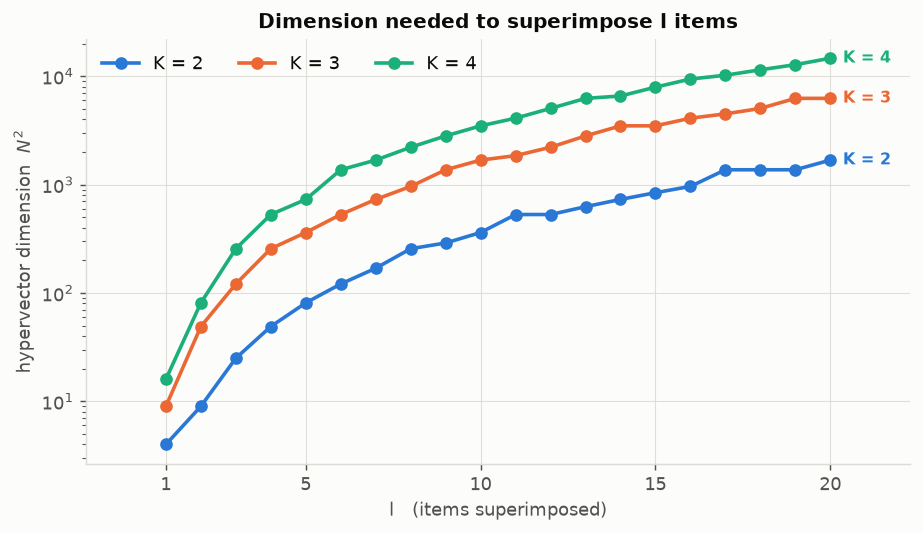

  l |        K=2        K=3        K=4
----------------------------------------
  1 |          4          9         16
  2 |          9         49         81
  4 |         49        256        529
  8 |        256        961       2209
 12 |        529       2209       5041
 16 |        961       4096       9409
 20 |       1681       6241      14641

Dimension grows like l^2: N must clear (K-1)(2l-1), and dim = N^2.


In [12]:
# --- figure 1: the dimension cost of l, one line per K -------------------------------
LS = list(range(1, 21))
KS = [2, 3, 4]
dims = {K: [dim_for(K, l) for l in LS] for K in KS}

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for i, K in enumerate(KS):
    ax.plot(LS, dims[K], color=PAL["series"][i], marker="o", label=f"K = {K}")
    ax.annotate(f"K = {K}", (LS[-1], dims[K][-1]), xytext=(7, 0),
                textcoords="offset points", color=PAL["series"][i],
                va="center", fontsize=9, fontweight="bold")
ax.set_yscale("log")
ax.set_xlabel("l   (items superimposed)")
ax.set_ylabel("hypervector dimension  $N^2$")
ax.set_title("Dimension needed to superimpose l items")
ax.set_xticks([1, 5, 10, 15, 20])
ax.margins(x=0.12)
ax.legend(loc="upper left", ncols=3)
fig.tight_layout()
fig.savefig("figures/dim_vs_l.png", bbox_inches="tight")
plt.show()

print(f"{'l':>3} | " + " ".join(f"{'K=' + str(K):>10}" for K in KS))
print("-" * 40)
for j, l in enumerate(LS):
    if l in (1, 2, 4, 8, 12, 16, 20):
        print(f"{l:>3} | " + " ".join(f"{dims[K][j]:>10}" for K in KS))
print("\nDimension grows like l^2: N must clear (K-1)(2l-1), and dim = N^2.")

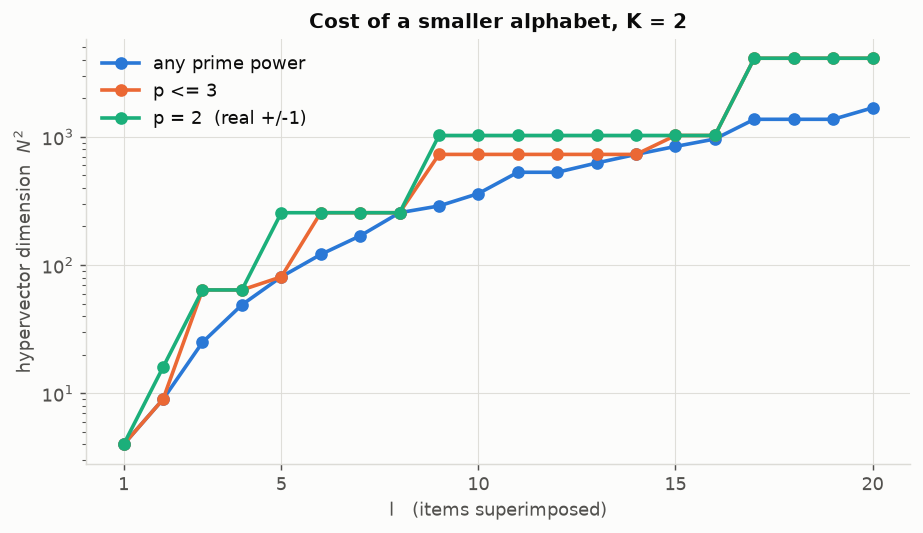

  l |    any prime power             p <= 3 p = 2  (real +/-1)
--------------------------------------------------------------
  2 |                  9                  9                 16
  4 |                 49                 64                 64
  8 |                256                256                256
 16 |                961               1024               1024
 20 |               1681               4096               4096

p = 2 pays in dimension, since N rounds up to a power of two, and is repaid
in alphabet: two phase values instead of many, so hypervectors are real.


In [13]:
# --- figure 2: what capping the alphabet costs, at K = 2 -----------------------------
CAPS = [(None, "any prime power"), (3, "p <= 3"), (2, "p = 2  (real +/-1)")]
curves = {lab: [dim_for(2, l, max_p=cap) for l in LS] for cap, lab in CAPS}

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for i, (cap, lab) in enumerate(CAPS):
    ax.plot(LS, curves[lab], color=PAL["series"][i], marker="o", label=lab)
ax.set_yscale("log")
ax.set_xlabel("l   (items superimposed)")
ax.set_ylabel("hypervector dimension  $N^2$")
ax.set_title("Cost of a smaller alphabet, K = 2")
ax.set_xticks([1, 5, 10, 15, 20])
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig("figures/dim_vs_l_alphabet.png", bbox_inches="tight")
plt.show()

print(f"{'l':>3} | " + " ".join(f"{lab:>18}" for _, lab in CAPS))
print("-" * 62)
for j, l in enumerate(LS):
    if l in (2, 4, 8, 16, 20):
        print(f"{l:>3} | " + " ".join(f"{curves[lab][j]:>18}" for _, lab in CAPS))
print("\np = 2 pays in dimension, since N rounds up to a power of two, and is repaid")
print("in alphabet: two phase values instead of many, so hypervectors are real.")

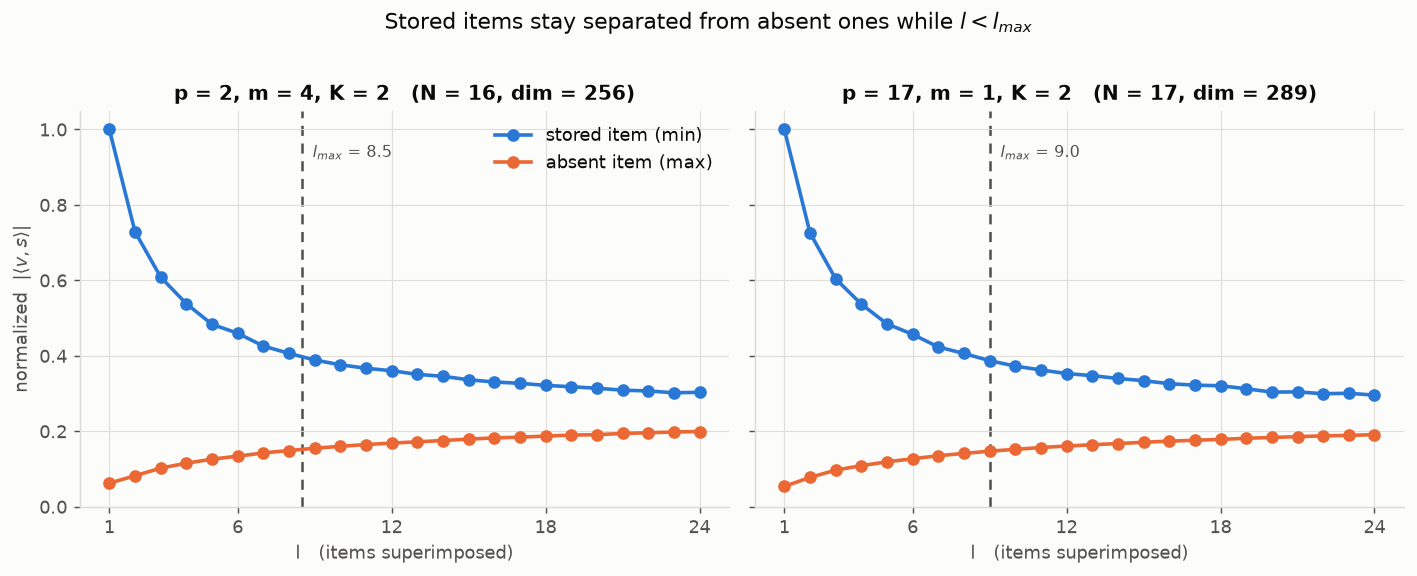


p=2 m=4 K=2  N=16  l_max=8.50
  l  stored(min)  absent(max)    margin
  1        1.000        0.062     0.938
  2        0.729        0.082     0.647
  4        0.538        0.115     0.423
  8        0.407        0.149     0.258
 12        0.361        0.169     0.192
 16        0.331        0.182     0.148
 20        0.314        0.191     0.123
 24        0.303        0.199     0.104

p=17 m=1 K=2  N=17  l_max=9.00
  l  stored(min)  absent(max)    margin
  1        1.000        0.054     0.946
  2        0.726        0.078     0.648
  4        0.537        0.109     0.428
  8        0.406        0.141     0.265
 12        0.353        0.161     0.192
 16        0.326        0.174     0.152
 20        0.304        0.184     0.120
 24        0.296        0.191     0.105


In [14]:
# --- figure 3: measured separation as l grows ---------------------------------------
def separation_sweep(code, ls, trials, rng):
    """Per l: mean over trials of (min stored similarity, max absent similarity)."""
    stored, absent = [], []
    root_dim = np.sqrt(code.dim)
    for l in ls:
        s_lo, a_hi = [], []
        for _ in range(trials):
            msgs = code.random_messages(min(2 * l, code.size), rng)
            V = np.array([code.encode(u) for u in msgs[:l]])
            W = np.array([code.encode(u) for u in msgs[l:]])
            s = V.sum(axis=0)
            denom = np.linalg.norm(s) * root_dim
            s_lo.append(np.abs(V.conj() @ s).min() / denom)
            a_hi.append(np.abs(W.conj() @ s).max() / denom if len(W) else np.nan)
        stored.append(np.mean(s_lo))
        absent.append(np.mean(a_hi))
    return np.array(stored), np.array(absent)


SWEEP_LS = list(range(1, 25))
CODES = [Code(2, 4, 2), Code(17, 1, 2)]    # N = 16 vs 17: same theory, alphabet 2 vs 17

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3), sharey=True)
rows = []
for ax, code in zip(axes, CODES):
    st, ab = separation_sweep(code, SWEEP_LS, trials=12, rng=np.random.default_rng(1))
    rows.append((code, st, ab))
    ax.plot(SWEEP_LS, st, color=PAL["series"][0], marker="o", label="stored item (min)")
    ax.plot(SWEEP_LS, ab, color=PAL["series"][1], marker="o", label="absent item (max)")
    ax.axvline(code.l_max, color=PAL["ink2"], linestyle=(0, (4, 3)), linewidth=1.4,
               zorder=1)
    ax.annotate(f"$l_{{max}}$ = {code.l_max:.1f}", (code.l_max, 0.96),
                xytext=(6, 0), textcoords="offset points", color=PAL["ink2"],
                fontsize=9, va="top")
    ax.set_title(f"p = {code.p}, m = {code.m}, K = {code.K}"
                 f"   (N = {code.N}, dim = {code.dim})")
    ax.set_xlabel("l   (items superimposed)")
    ax.set_xticks([1, 6, 12, 18, 24])
axes[0].set_ylabel("normalized  $|\\langle v, s \\rangle|$")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="upper right")
fig.suptitle("Stored items stay separated from absent ones while $l < l_{max}$", y=1.02)
fig.tight_layout()
fig.savefig("figures/separation_vs_l.png", bbox_inches="tight")
plt.show()

for code, st, ab in rows:
    print(f"\np={code.p} m={code.m} K={code.K}  N={code.N}  l_max={code.l_max:.2f}")
    print(f"{'l':>3} {'stored(min)':>12} {'absent(max)':>12} {'margin':>9}")
    for j, l in enumerate(SWEEP_LS):
        if l in (1, 2, 4, 8, 12, 16, 20, 24):
            print(f"{l:>3} {st[j]:>12.3f} {ab[j]:>12.3f} {st[j] - ab[j]:>9.3f}")

### Reading figure 3

Stored-item similarity falls off like $1/\sqrt{l}$ --- the superposition's norm grows as
$\sqrt{l}$ while the signal term stays fixed --- and absent-item similarity climbs like
$\sqrt{l}\,\mu$ as cross terms accumulate. The two must therefore meet, and the gap
between them is the margin a similarity readout has to work with.

Two things are worth noticing. The margin at $l_{\max}$ is still wide, so the bound is
conservative rather than tight: it is a sufficient condition for retrieval, not the point
where retrieval fails. And the two panels track each other closely despite one having a
2-symbol alphabet and the other 17 --- the concrete form of the claim that the figures of
merit depend on $N$ alone, not on how $N$ factors into $p^m$.